# So sánh hiệu suất mô hình Link Prediction trên đồ án Amazon co-purchase


### Phan 1: Import thư viện

In [12]:
from pathlib import Path
import sys
import pickle
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

### Cell 2 — Khai báo đường dẫn project và import từ src

In [13]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT / "src"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("SRC_DIR exists =", SRC_DIR.exists())

from src.evaluator import run_model_comparison

PROJECT_ROOT = C:\Users\ADMIN\python\Amazon-Graph-Recommender
SRC_DIR exists = True


### Cell 3 — Khai báo path file dữ liệu

In [14]:
DEFAULT_DATA_PATH = Path(r"C:\Users\ADMIN\python\Amazon-Graph-Recommender\data\processed\amazon_lcc_cleaned.pkl")

LOCAL_FALLBACKS = [
    PROJECT_ROOT / "data" / "processed" / "amazon_lcc_cleaned.pkl",
    Path("amazon_lcc_cleaned.pkl"),
]

print("Default data path =", DEFAULT_DATA_PATH)

Default data path = C:\Users\ADMIN\python\Amazon-Graph-Recommender\data\processed\amazon_lcc_cleaned.pkl


### Cell 4 — Hàm load graph từ .pkl

In [15]:
def load_graph_from_pickle(data_path: Path | None = None) -> nx.Graph:
    candidate_paths = []

    if data_path is not None:
        candidate_paths.append(Path(data_path))

    candidate_paths.append(DEFAULT_DATA_PATH)
    candidate_paths.extend(LOCAL_FALLBACKS)

    existing_path = None
    for path in candidate_paths:
        path = Path(path)
        if path.exists():
            existing_path = path
            break

    if existing_path is None:
        raise FileNotFoundError(
            "Không tìm thấy file amazon_lcc_cleaned.pkl. "
            "Hãy kiểm tra lại path trong notebook."
        )

    with open(existing_path, "rb") as f:
        obj = pickle.load(f)

    if isinstance(obj, nx.Graph):
        G = obj

    elif isinstance(obj, dict):
        if "graph" in obj and isinstance(obj["graph"], nx.Graph):
            G = obj["graph"]
        elif "G" in obj and isinstance(obj["G"], nx.Graph):
            G = obj["G"]
        elif "edges" in obj:
            G = nx.Graph()
            G.add_edges_from(obj["edges"])
        else:
            raise TypeError(
                f"Pickle là dict nhưng chưa biết cách dựng graph từ keys: {list(obj.keys())[:10]}"
            )

    elif hasattr(obj, "edges") and callable(obj.edges):
        G = nx.Graph(obj)

    else:
        raise TypeError(f"Không hỗ trợ kiểu dữ liệu trong pickle: {type(obj)}")

    G = nx.Graph(G)
    G.remove_edges_from(nx.selfloop_edges(G))

    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()

    print("Loaded from:", existing_path)
    print("Nodes      :", G.number_of_nodes())
    print("Edges      :", G.number_of_edges())
    print("Density    :", f"{nx.density(G):.8f}")

    return G

G = load_graph_from_pickle()

Loaded from: C:\Users\ADMIN\python\Amazon-Graph-Recommender\data\processed\amazon_lcc_cleaned.pkl
Nodes      : 334863
Edges      : 925872
Density    : 0.00001651


### Cell 6 — Thiết lập tham số thí nghiệm

In [16]:
SEED = 42
TEST_FRAC = 0.20
VAL_FRAC = 0.10

NODE2VEC_PARAMS = {
    "run_node2vec": True,
    "node2vec_subgraph_size": 5000,
    "node2vec_dimensions": 32,
    "node2vec_walk_length": 10,
    "node2vec_num_walks": 3,
    "node2vec_epochs": 1,
    "node2vec_batch_size": 256,
}

### Cell 7 — Chạy so sánh mô hình

In [17]:
result = run_model_comparison(
    G,
    test_frac=TEST_FRAC,
    val_frac=VAL_FRAC,
    seed=SEED,
    **NODE2VEC_PARAMS,
)

print("Train nodes           :", result.n_nodes_train)
print("Train edges           :", result.n_edges_train)
print("Positive test edges   :", result.n_pos_test)
print("Negative test pairs   :", result.n_neg_test)
print("Node2Vec used subgraph:", result.node2vec_used_subgraph)
print("Node2Vec subgraph size:", result.node2vec_subgraph_size)
print("Node2Vec report       :", result.report_node2vec)

Đang chạy dự đoán liên kết cho 370348 cặp sản phẩm...
- Tính Jaccard...
- Tính Adamic-Adar...
Hoàn thành dự đoán! Thời gian: 4.89s
Đang chạy thuật toán Louvain Community Detection...
Hoàn thành! Tìm thấy 229 cộng đồng. Thời gian: 42.39s
Train nodes           : 334863
Train edges           : 648111
Positive test edges   : 185174
Negative test pairs   : 185174
Node2Vec used subgraph: True
Node2Vec subgraph size: 5000
Node2Vec report       : LinkPredictionReport(auc=0.5017307558083476, ap=0.5018529871259636, precision=0.5, recall=1.0, f1=0.6666666666666666, threshold=-0.9870519157096208)


In [18]:
def report_to_row(name, report):
    if report is None:
        return {
            "Model": name,
            "Precision": np.nan,
            "Recall": np.nan,
            "AUC": np.nan,
            "AP": np.nan,
            "F1": np.nan,
            "Threshold": np.nan,
        }

    return {
        "Model": name,
        "Precision": report.precision,
        "Recall": report.recall,
        "AUC": report.auc,
        "AP": report.ap,
        "F1": report.f1,
        "Threshold": report.threshold,
    }

results_df = pd.DataFrame([
    report_to_row("Jaccard", result.report_jaccard),
    report_to_row("Adamic-Adar", result.report_adamic),
    report_to_row("Node2Vec", result.report_node2vec),
])

results_df = results_df.sort_values(by="AUC", ascending=False).reset_index(drop=True)
results_df

,Model,Precision,Recall,AUC,AP,F1,Threshold
0,Adamic-Adar,0.999898,0.579849,0.789906,0.789909,0.734029,0.167185
1,Jaccard,0.999898,0.579849,0.789899,0.789888,0.734029,0.002463
2,Node2Vec,0.500000,1.000000,0.501731,0.501853,0.666667,-0.987052


In [19]:
topology_df = pd.DataFrame([{
    "Average Clustering": result.avg_clustering,
    "Modularity": result.modularity,
    "Num Communities": result.num_communities,
    "Train Nodes": result.n_nodes_train,
    "Train Edges": result.n_edges_train,
    "Positive Test Edges": result.n_pos_test,
    "Negative Test Pairs": result.n_neg_test,
}])

topology_df

,Average Clustering,Modularity,Num Communities,Train Nodes,Train Edges,Positive Test Edges,Negative Test Pairs
0,0.396746,0.925789,229,334863,648111,185174,185174


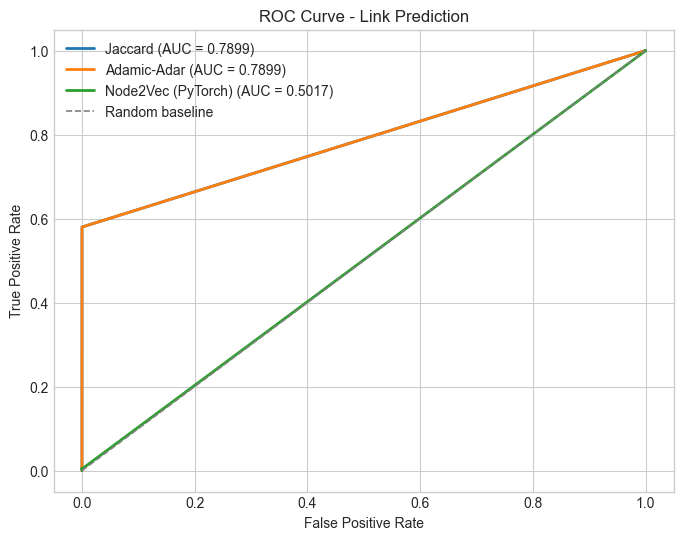

In [20]:
def plot_roc_curve(pos_scores, neg_scores, label, ax):
    y_true = np.array([1] * len(pos_scores) + [0] * len(neg_scores))
    y_score = np.array(list(pos_scores) + list(neg_scores))

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC = {roc_auc:.4f})")

fig, ax = plt.subplots(figsize=(8, 6))

plot_roc_curve(result.jacc_pos, result.jacc_neg, "Jaccard", ax)
plot_roc_curve(result.adam_pos, result.adam_neg, "Adamic-Adar", ax)

if result.report_node2vec is not None and len(result.n2v_pos) > 0 and len(result.n2v_neg) > 0:
    plot_roc_curve(result.n2v_pos, result.n2v_neg, "Node2Vec (PyTorch)", ax)

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.2, color="gray", label="Random baseline")
ax.set_title("ROC Curve - Link Prediction")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.show()